# UPI Transaction Analysis

# _________________________________________________________________________________

In [1]:
import pandas as pd
import pymysql
from sqlalchemy import create_engine, text
import os

## Data Pipeline Connecting SQL to Python

### ___________________________________________________________________________________________________________________________

In [2]:
# Create dotenv file

with open('.env','w') as f:
    f.write(
        '''
        DB_USER = root
        DB_PASSWORD = abcd1234
        DB_HOST = localhost
        DB_PORT = 3306
        DB_NAME = upi_capstone
        '''
    )

print('dotenv file created successfully...')

dotenv file created successfully...


In [3]:
# Engine creation

from dotenv import load_dotenv
load_dotenv()

DB_USER = os.getenv('DB_USER')
DB_PASSWORD = os.getenv('DB_PASSWORD')
DB_HOST = os.getenv('DB_HOST')
DB_PORT = os.getenv('DB_PORT')
DB_NAME = os.getenv('DB_NAME')

engine = create_engine(
    f'mysql+pymysql://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}'
)

print('Engine created successfully...')


Engine created successfully...


In [4]:
# Test connection

with engine.connect() as conn:
    result = conn.execute(text('SELECT 1'))
    print(f'Connection established successfully: {result.fetchone()}')

Connection established successfully: (1,)


## Data Loading and transformation

# __________________________________________________________________________________

In [5]:
# Load tables to python

tables = [
    'customer_feedback',
    'customer_master',
    'device_info',
    'fraud_alert_history',
    'merchant_info',
    'upi_account',
    'upi_transactions_history'
]

# dataframes

dataframes = {}

for table in tables:
    query = f'SELECT * FROM {table}'
    df = pd.read_sql_query(query,engine)
    dataframes[table] = df
    print(f'Loaded {table} : {df.shape}')

Loaded customer_feedback : (4000, 7)
Loaded customer_master : (10000, 9)
Loaded device_info : (12000, 6)
Loaded fraud_alert_history : (2000, 7)
Loaded merchant_info : (500, 6)
Loaded upi_account : (12000, 6)
Loaded upi_transactions_history : (100000, 15)


###

# A. Data Cleaning

### Dataset 1: Customer Master

In [6]:
dataframes['customer_master'].head()

,customer_id,full_name,age,gender,region,date_joined,is_business_user,risk_score,mobile_number
0,CUST100000,Ryan Gallagher,26,Female,North,2024-01-28,0,0.39,7631706690
1,CUST100001,Robert Garza,49,Female,West,2025-04-16,0,0.13,806360837\r
2,CUST100002,Haley Rhodes,68,Male,West,2022-02-10,1,0.14,8124158683
3,CUST100003,Sonya Mathis,42,Male,North,2021-02-18,0,0.07,3662585178
4,CUST100004,Ryan Wood,35,Female,South,2023-04-17,0,0.30,9996228303


In [7]:
# Customer_master dataset overview

dataframes['customer_master'].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       10000 non-null  object 
 1   full_name         10000 non-null  object 
 2   age               10000 non-null  int64  
 3   gender            10000 non-null  object 
 4   region            10000 non-null  object 
 5   date_joined       10000 non-null  object 
 6   is_business_user  10000 non-null  int64  
 7   risk_score        10000 non-null  float64
 8   mobile_number     10000 non-null  object 
dtypes: float64(1), int64(2), object(6)
memory usage: 703.3+ KB


In [8]:
dataframes['customer_master']['date_joined'] = pd.to_datetime(dataframes['customer_master']['date_joined'],
                                                              format="%Y-%m-%d")

In [9]:
dataframes['customer_master']['gender'].value_counts()

gender
Male      4952
Female    4844
Other      204
Name: count, dtype: int64

In [10]:
# Check for missing values
dataframes['customer_master'].isnull().sum()

customer_id         0
full_name           0
age                 0
gender              0
region              0
date_joined         0
is_business_user    0
risk_score          0
mobile_number       0
dtype: int64

In [11]:
# Describe
dataframes['customer_master'][['age','risk_score']].describe().round(2)

,age,risk_score
count,10000.00,10000.00
mean,44.05,0.20
std,15.25,0.12
min,18.00,0.00
25%,31.00,0.12
50%,44.00,0.20
75%,57.00,0.28
max,70.00,0.68


##

### Dataset 2: Device info

In [12]:
dataframes['device_info'].head()

,device_id,customer_id,device_type,app_version,is_rooted,last_active
0,DEV100000,CUST100000,Android,2.5.4,0,2024-10-19 01:24:00
1,DEV100001,CUST100001,Feature_Phone,2.6.18,0,2025-07-16 01:53:00
2,DEV100002,CUST100002,Android,2.5.0,0,2024-04-25 05:09:00
3,DEV100003,CUST100003,Android,2.4.12,0,2021-04-24 19:10:00
4,DEV100004,CUST100004,Feature_Phone,4.2.0,0,2024-09-15 01:18:00


In [13]:
# Check for missing values

dataframes['device_info'].isnull().sum()

device_id      0
customer_id    0
device_type    0
app_version    0
is_rooted      0
last_active    0
dtype: int64

In [14]:
# check for dataset info

dataframes['device_info'].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   device_id    12000 non-null  object        
 1   customer_id  12000 non-null  object        
 2   device_type  12000 non-null  object        
 3   app_version  12000 non-null  object        
 4   is_rooted    12000 non-null  int64         
 5   last_active  12000 non-null  datetime64[ns]
dtypes: datetime64[ns](1), int64(1), object(4)
memory usage: 562.6+ KB


In [15]:
# Check for categorical column

dataframes['device_info']['device_type'].value_counts()

device_type
Ios              3032
Android          3018
Tablet           2978
Feature_Phone    2972
Name: count, dtype: int64

##

### Dataset 3: Merchant_info

In [16]:
dataframes['merchant_info'].head()

,merchant_id,merchant_name,merchant_type,region,onboard_date,risk_score
0,MERCH1000,Anderson Inc,Grocery,North,2022-01-14,0.07
1,MERCH1001,"Rojas, Newton And White",Online,North,2021-08-20,0.29
2,MERCH1002,Knox-Reyes,Food,West,2024-10-29,0.20
3,MERCH1003,"Joseph, Serrano And Gilmore",Grocery,North,2023-07-22,0.14
4,MERCH1004,Brown-Jones,Food,North,2024-01-02,0.32


In [17]:
# Check for missing or null values

dataframes['merchant_info'].isnull().sum()

merchant_id      0
merchant_name    0
merchant_type    0
region           0
onboard_date     0
risk_score       0
dtype: int64

In [18]:
# Check for data types 

dataframes['merchant_info'].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   merchant_id    500 non-null    object 
 1   merchant_name  500 non-null    object 
 2   merchant_type  500 non-null    object 
 3   region         500 non-null    object 
 4   onboard_date   500 non-null    object 
 5   risk_score     500 non-null    float64
dtypes: float64(1), object(5)
memory usage: 23.6+ KB


In [19]:
# Convert onboard date to date column

dataframes['merchant_info']['onboard_date'] = pd.to_datetime(dataframes['merchant_info']['onboard_date'],
                                                            format= '%Y-%m-%d')

In [20]:
# Check for categorical columns

dataframes['merchant_info']['merchant_type'].value_counts()

merchant_type
Apparel        98
Electronics    91
Online         86
Food           80
Grocery        75
Transport      70
Name: count, dtype: int64

In [21]:
# Describe fact columns

dataframes['merchant_info']['risk_score'].describe().round(2)

count    500.00
mean       0.18
std        0.12
min        0.00
25%        0.09
50%        0.17
75%        0.26
max        0.50
Name: risk_score, dtype: float64

#

### Dataset 4: UPI Account

In [22]:
dataframes['upi_account'].head()

,upi_id,customer_id,bank_name,account_type,date_added,status
0,aaron1106@upi,CUST108503,ICICI,Credit_Card_Linked,2025-06-09,Active\r
1,aaron1337@upi,CUST106141,KOTAK,Current,2025-03-28,Active\r
2,aaron1366@upi,CUST106060,KOTAK,Current,2025-05-25,Active\r
3,aaron1526@upi,CUST103772,SBI,Current,2022-12-31,Active\r
4,aaron1785@upi,CUST105135,KOTAK,Current,2024-02-19,Blocked\r


In [23]:
# Check for missing values

dataframes['upi_account'].isnull().sum()

upi_id          0
customer_id     0
bank_name       0
account_type    0
date_added      0
status          0
dtype: int64

In [24]:
# Check for datatypes

dataframes['upi_account'].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   upi_id        12000 non-null  object
 1   customer_id   12000 non-null  object
 2   bank_name     12000 non-null  object
 3   account_type  12000 non-null  object
 4   date_added    12000 non-null  object
 5   status        12000 non-null  object
dtypes: object(6)
memory usage: 562.6+ KB


In [25]:
# Convert date_added to date column

dataframes['upi_account']['date_added'] = pd.to_datetime(dataframes['upi_account']['date_added'],
                                                        format= '%Y-%m-%d')

In [26]:
# Check for categorical values

dataframes['upi_account']['bank_name'].value_counts()

bank_name
SBI      2036
KOTAK    2010
ICICI    2001
PNB      1992
HDFC     1990
AXIS     1971
Name: count, dtype: int64

In [27]:
# striping \r in status column

dataframes['upi_account']['status'] = dataframes['upi_account']['status'].str.replace('\r','')
dataframes['upi_account']['status'] = dataframes['upi_account']['status'].str.strip()

# 

### Dataset 5: UPI_Transactions_History

In [28]:
dataframes['upi_transactions_history'].head()

,transaction_id,upi_id,customer_id,timestamp,amount,transaction_type,merchant_id,counterparty_upi,status,device_id,device_type,channel,fraud_flag,reversal_flag,failure_reason
0,TXN10000000,marisa9078@upi,CUST101488,2025-06-04 21:36:20,9.88,Send,None,user6545@upi,Success,DEV101488,Feature_Phone,App,0,0,\r
1,TXN10000001,michelle5950@upi,CUST107876,2025-05-22 04:26:44,76.25,Receive,None,user3199@upi,Success,DEV107876,Ios,App,0,0,\r
2,TXN10000002,jeffery4732@upi,CUST100901,2025-08-02 02:34:15,26.44,Merchant_Payment,MERCH1113,user4690@upi,Success,DEV100901,Android,Intent,0,0,\r
3,TXN10000003,troy1833@upi,CUST105890,2025-01-30 03:53:31,84.43,Send,None,user1982@upi,Success,DEV105890,Tablet,Qr_Code,0,0,\r
4,TXN10000004,tammy4986@upi,CUST106780,2025-07-05 21:36:53,10.33,Receive,None,user4914@upi,Success,DEV106780,Tablet,Qr_Code,0,0,\r


In [29]:
# Check for missing values

dataframes['upi_transactions_history'].isnull().sum()

transaction_id          0
upi_id                  0
customer_id             0
timestamp               0
amount                  0
transaction_type        0
merchant_id         69851
counterparty_upi        0
status                  0
device_id               0
device_type             0
channel                 0
fraud_flag              0
reversal_flag           0
failure_reason          0
dtype: int64

In [30]:
# Deal with missing Merchant Id

dataframes['upi_transactions_history']['merchant_id'] = (
    dataframes['upi_transactions_history']['merchant_id']
    .astype(str)
    .str.strip()
    .replace(['None','nan',''],None)
)


In [31]:
# Deal with \r in failure reason column

dataframes['upi_transactions_history']['failure_reason'] = dataframes['upi_transactions_history']['failure_reason'].str.replace('\r','')
dataframes['upi_transactions_history']['failure_reason'] = dataframes['upi_transactions_history']['failure_reason'].str.strip()

In [32]:
# Check for datatype

dataframes['upi_transactions_history'].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 15 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   transaction_id    100000 non-null  object        
 1   upi_id            100000 non-null  object        
 2   customer_id       100000 non-null  object        
 3   timestamp         100000 non-null  datetime64[ns]
 4   amount            100000 non-null  float64       
 5   transaction_type  100000 non-null  object        
 6   merchant_id       30149 non-null   object        
 7   counterparty_upi  100000 non-null  object        
 8   status            100000 non-null  object        
 9   device_id         100000 non-null  object        
 10  device_type       100000 non-null  object        
 11  channel           100000 non-null  object        
 12  fraud_flag        100000 non-null  int64         
 13  reversal_flag     100000 non-null  int64         
 14  failu

In [33]:
# Check for categorial columns

dataframes['upi_transactions_history']['transaction_type'].value_counts()

transaction_type
Send                35032
Receive             34819
Merchant_Payment    25097
Bill_Pay             5052
Name: count, dtype: int64

In [34]:
# Describe the numerical columns

dataframes['upi_transactions_history']['amount'].describe()

count    100000.000000
mean         42.417743
std          34.186004
min           1.620000
25%          20.690000
50%          33.090000
75%          53.170000
max         830.460000
Name: amount, dtype: float64

#

### Dataset 6: Customer_Feedback

In [35]:
dataframes['customer_feedback'].head()

,feedback_id,customer_id,date_submitted,feedback_text,satisfaction_score,issue_type,resolved
0,FDBK100000,CUST106029,2021-08-14,Weight what decision able gun shoulder.,4,Fraud,1
1,FDBK100001,CUST101758,2025-03-30,Case discuss approach leave hair.,3,Transaction,0
2,FDBK100002,CUST107269,2025-07-24,Idea as effect bed need shake.,4,App_Usability,0
3,FDBK100003,CUST108175,2024-06-07,Image design soldier strategy character learn ...,4,App_Usability,0
4,FDBK100004,CUST101420,2022-01-12,Two lose traditional approach commercial throw...,3,Transaction,1


In [36]:
# Check for missing values

dataframes['customer_feedback'].isnull().sum()

feedback_id           0
customer_id           0
date_submitted        0
feedback_text         0
satisfaction_score    0
issue_type            0
resolved              0
dtype: int64

In [37]:
# Check for data info

dataframes['customer_feedback'].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   feedback_id         4000 non-null   object
 1   customer_id         4000 non-null   object
 2   date_submitted      4000 non-null   object
 3   feedback_text       4000 non-null   object
 4   satisfaction_score  4000 non-null   int64 
 5   issue_type          4000 non-null   object
 6   resolved            4000 non-null   int64 
dtypes: int64(2), object(5)
memory usage: 218.9+ KB


In [38]:
# Convert date_submitted to date type column

dataframes['customer_feedback']['date_submitted'] = pd.to_datetime(dataframes['customer_feedback']['date_submitted'],
                                                                  format= '%Y-%m-%d')


In [39]:
# Check for categorical columns

dataframes['customer_feedback']['issue_type'].value_counts()

issue_type
Transaction      2025
App_Usability     796
Fraud             596
Other             583
Name: count, dtype: int64

#

### Dataset 7: Fraud Alert History

In [40]:
dataframes['fraud_alert_history'].head()

,alert_id,transaction_id,alert_type,alert_date,resolved,resolution_date,remarks
0,ALERT100022,TXN10000022,Frequent_Failure,2025-06-28 16:15:37,1,2025-06-29 23:15:37,Career including meet defense.\r
1,ALERT100052,TXN10000052,Suspicious_Login,2024-10-06 01:00:25,0,0000-00-00 00:00:00,Letter support standard glass decide.\r
2,ALERT100067,TXN10000067,Suspicious_Login,2025-02-20 19:40:33,1,2025-02-22 01:40:33,Hard direction none team.\r
3,ALERT100235,TXN10000235,Unusual_Amount,2024-11-15 15:00:38,1,2024-11-18 12:00:38,Now name ok but current religious.\r
4,ALERT100383,TXN10000383,Unusual_Time,2025-01-19 07:20:06,0,0000-00-00 00:00:00,Sound leader very step pass scene nation.\r


In [41]:
# Check for missing values

dataframes['fraud_alert_history'].isnull().sum()

alert_id           0
transaction_id     0
alert_type         0
alert_date         0
resolved           0
resolution_date    0
remarks            0
dtype: int64

In [42]:
# Dataset info

dataframes['fraud_alert_history'].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   alert_id         2000 non-null   object        
 1   transaction_id   2000 non-null   object        
 2   alert_type       2000 non-null   object        
 3   alert_date       2000 non-null   datetime64[ns]
 4   resolved         2000 non-null   int64         
 5   resolution_date  2000 non-null   object        
 6   remarks          2000 non-null   object        
dtypes: datetime64[ns](1), int64(1), object(5)
memory usage: 109.5+ KB


In [43]:
# Convert resolution date into date column

dataframes['fraud_alert_history']['resolution_date'] = pd.to_datetime(dataframes['fraud_alert_history']['resolution_date'],errors='coerce')

In [44]:
# remove \r from remarks column

dataframes['fraud_alert_history']['remarks'] = dataframes['fraud_alert_history']['remarks'].str.replace('\r','')
dataframes['fraud_alert_history']['remarks'] = dataframes['fraud_alert_history']['remarks'].str.replace('\r','')


#

# B. Derived columns

### 1. Age group in customer_master

In [45]:
# 1. Age_group column : Senior above aged 55 and mid aged 35-55 and young <=35

bins = [0,35,55,100]

labels = ['Young','Mid-aged','Senior']

dataframes['customer_master']['age_group'] = pd.cut(dataframes['customer_master']['age']
                                                    ,bins= bins, labels= labels, right= True)


### 2. Customer_risk Category in customer_master

In [46]:
# Risk category

dataframes['customer_master']['risk_score'].describe().round(2)

risk_value = [-0.10,0.00,0.20,0.50,1.00]
risk_labels = ['No Risk','Low Risk','Moderate Risk','High Risk']

dataframes['customer_master']['risk_category'] = pd.cut(dataframes['customer_master']['risk_score'],
                                                       bins= risk_value, labels= risk_labels, right= True)

In [47]:
dataframes['upi_transactions_history']['month_year'] = dataframes['upi_transactions_history']['timestamp'].dt.strftime('%b-%Y')
dataframes['upi_transactions_history']['year'] = dataframes['upi_transactions_history']['timestamp'].dt.strftime('%Y')


### 3. Satisfaction Level in customer feedback

In [48]:
# Satisfaction level

score = [1,2,4,5]
level = ['Least Satisfied','Moderately Satisfied','Highly Satisfied']

dataframes['customer_feedback']['satisfaction_level'] = pd.cut(dataframes['customer_feedback']['satisfaction_score'],
                                                              bins = score, labels = level,right= True)

#

# C. EDA

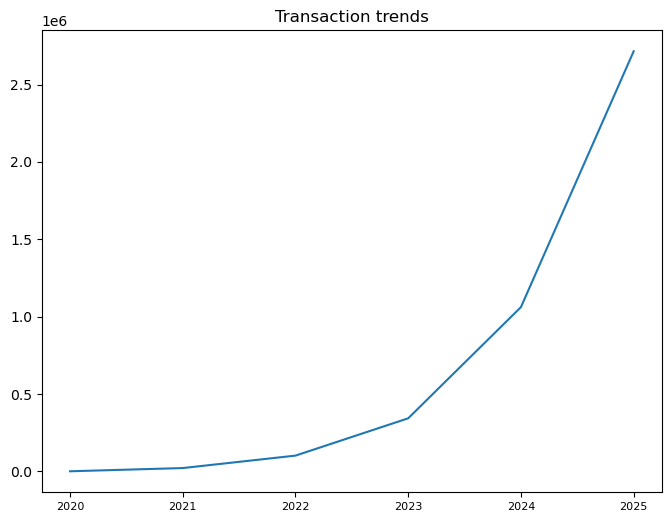

In [49]:
# Visualising monthly trandsactions
import seaborn as sns
import matplotlib.pyplot as plt

monthly_sales = dataframes['upi_transactions_history'].groupby('year')['amount'].sum().reset_index()
monthly_sales.set_index('year',inplace=True)

#plotting transaction trends

plt.figure(figsize=(8,6))
plt.plot(monthly_sales.index, monthly_sales.values)
plt.title('Transaction trends')
plt.xticks(rotation=0,fontsize= 8)
plt.show()

In [50]:
# Mergeing table

merged_df = dataframes['upi_transactions_history'].merge(
    dataframes['customer_master'][['customer_id','region']],
    on = 'customer_id',
    how = 'left'
)

merged_df = merged_df.merge(
    dataframes['merchant_info'][['merchant_id','merchant_name']],
    on = 'merchant_id',
    how = 'left'
)

merged_df.head()

,transaction_id,upi_id,customer_id,timestamp,amount,transaction_type,merchant_id,counterparty_upi,status,device_id,device_type,channel,fraud_flag,reversal_flag,failure_reason,month_year,year,region,merchant_name
0,TXN10000000,marisa9078@upi,CUST101488,2025-06-04 21:36:20,9.88,Send,None,user6545@upi,Success,DEV101488,Feature_Phone,App,0,0,,Jun-2025,2025,East,NaN
1,TXN10000001,michelle5950@upi,CUST107876,2025-05-22 04:26:44,76.25,Receive,None,user3199@upi,Success,DEV107876,Ios,App,0,0,,May-2025,2025,Central,NaN
2,TXN10000002,jeffery4732@upi,CUST100901,2025-08-02 02:34:15,26.44,Merchant_Payment,MERCH1113,user4690@upi,Success,DEV100901,Android,Intent,0,0,,Aug-2025,2025,Central,Woods-Stewart
3,TXN10000003,troy1833@upi,CUST105890,2025-01-30 03:53:31,84.43,Send,None,user1982@upi,Success,DEV105890,Tablet,Qr_Code,0,0,,Jan-2025,2025,East,NaN
4,TXN10000004,tammy4986@upi,CUST106780,2025-07-05 21:36:53,10.33,Receive,None,user4914@upi,Success,DEV106780,Tablet,Qr_Code,0,0,,Jul-2025,2025,Central,NaN


### Revenue trend by region

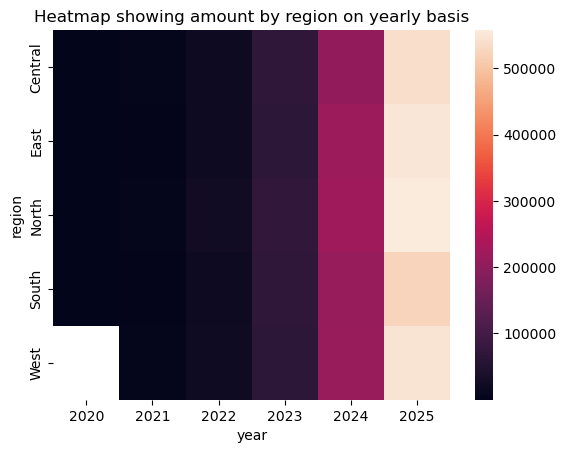

In [51]:
# Region by amount on year basis

## Pivot region


pivot_region = merged_df.pivot_table(
    values = 'amount',
    index = 'region',
    columns = 'year',
    aggfunc = 'sum'
)

sns.heatmap(pivot_region)
plt.title('Heatmap showing amount by region on yearly basis')
plt.show()

### Revenue trend by Merchant

<Axes: xlabel='year', ylabel='merchant_name'>

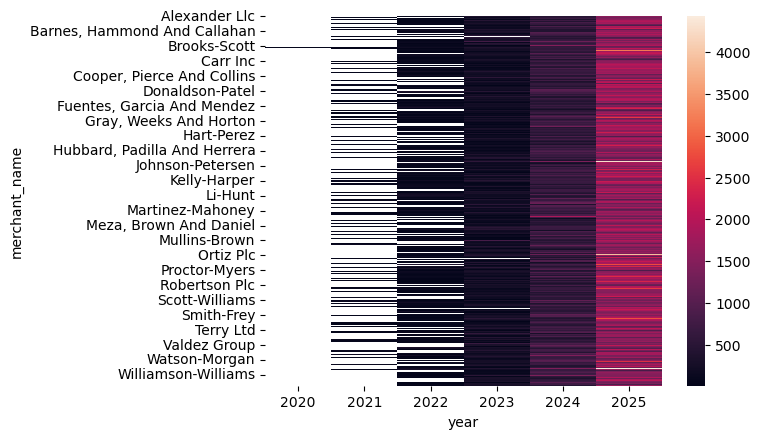

In [52]:
# Merchant wise amount

pivot_merchant = merged_df.pivot_table(
    values = 'amount',
    index = 'merchant_name',
    columns = 'year',
    aggfunc = 'sum'
)

sns.heatmap(pivot_merchant)

### Volume of transactions by device type

Text(0.5, 1.0, 'Volume of transactions through the year by device type')

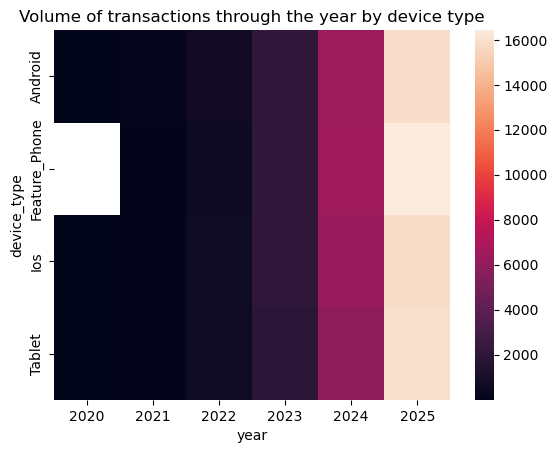

In [53]:
# Device type volume of transations

pivot_device = merged_df.pivot_table(
    values = 'transaction_id',
    index = 'device_type',
    columns = 'year',
    aggfunc = 'count'
)

sns.heatmap(pivot_device)
plt.title('Volume of transactions through the year by device type')


# _______________________________________________________________________________________

# Statistical Analysis

## SA: OneWay ANOVA test - Spending through device types

In [54]:
tran_df = dataframes['upi_transactions_history'].copy()

F-Stat: 0.53
P-Value: 0.66

No significant difference in spending among device type


<Figure size 640x480 with 0 Axes>

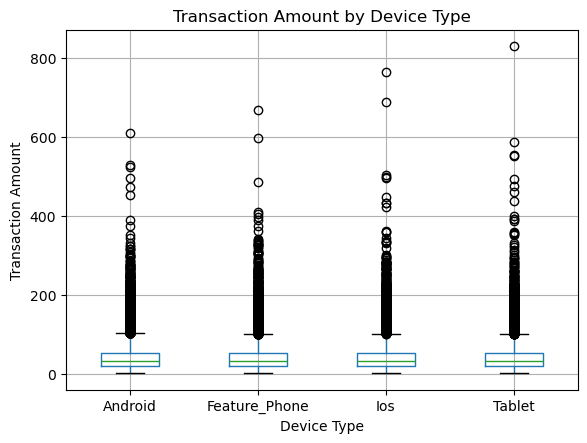

In [55]:
# Create a group

from scipy.stats import f_oneway

groups = [
    tran_df[tran_df['device_type']=='Feature_Phone']['amount'],
    tran_df[tran_df['device_type']=='Android']['amount'],
    tran_df[tran_df['device_type']=='Ios']['amount'],
    tran_df[tran_df['device_type']=='Tablet']['amount']
]

f_stat, p_value = f_oneway(*groups)

print(f'F-Stat: {f_stat:.2f}')
print(f'P-Value: {p_value:.2f}')

# Interpretation
if p_value<0.05:
    print('\nAt least one device_type has different spending.')
else:
    print('\nNo significant difference in spending among device type')


import matplotlib.pyplot as plt

plt.figure()
tran_df.boxplot(column='amount', by='device_type')

plt.title('Transaction Amount by Device Type')
plt.suptitle('')  # removes extra default title
plt.xlabel('Device Type')
plt.ylabel('Transaction Amount')

plt.show()

## SA: OneWay ANOVA test - Between Fraud rates & Merchant Type

In [56]:
# Fraud alert
# Merge merchant table with upi_transactions

merchant = dataframes['merchant_info'].copy()
tran_df = dataframes['upi_transactions_history'].copy()

merc_tran_df = tran_df.merge(merchant,on='merchant_id',how='left')

In [57]:
# Anova test to check variability of fraud rates by merchant type or region.

from scipy import stats

groups = [
    group['fraud_flag'].values
    for _, group in merc_tran_df.groupby('merchant_type')
]

f_stat, p_value = stats.f_oneway(*groups)

print(f'F-Stat: {f_stat:.3f}')
print(f'P-Value: {p_value:.3f}')

# Interpretation

if p_value>=0.05:
    print('There is no significant difference in fraud rates among different merchant type.')
else:
    print('There are at least two different merchant type having difference in fraud rates')
    

F-Stat: 0.693
P-Value: 0.628
There is no significant difference in fraud rates among different merchant type.


## SA: OneWay ANOVA test - Between Fraud Rates & Region

In [58]:
# By region

groups_region = [
    group['fraud_flag'].values
    for _, group in merc_tran_df.groupby('region')
]

f_stat, p_value = stats.f_oneway(*groups_region)

print(f'F-Stat: {f_stat:.3f}')
print(f'P-Value: {p_value:.3f}')


if p_value>= 0.05:
    print('There is no significant difference in fraud rates across regions.')

else:
    print('There is at least two different region with difference in fraud rates.')

F-Stat: 0.794
P-Value: 0.529
There is no significant difference in fraud rates across regions.


## SA: Chi2 test - Test association between Fraud Flag and channel

Chi2: 3.884
P-value: 0.143
There is no evidence of association of fraud and channel.


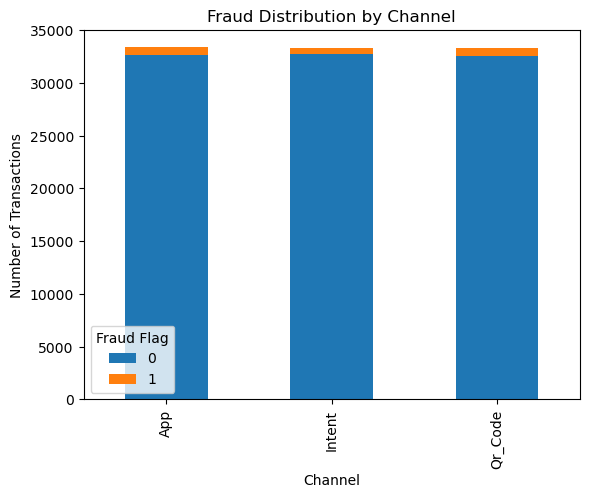

In [59]:
# Chi2 Test to test the association between fraud flag and channel or transaction status and device type


from scipy.stats import chi2_contingency

table = pd.crosstab(merc_tran_df['channel'],merc_tran_df['fraud_flag'])

# test

chi2, p, dof, expected = chi2_contingency(table)
print(f'Chi2: {chi2:.3f}')
print(f'P-value: {p:.3f}')


if p >= 0.05:
    print('There is no evidence of association of fraud and channel.')

else:
    print('There is association of fraud and channel.')

import matplotlib.pyplot as plt

table.plot(kind='bar', stacked=True)

plt.title('Fraud Distribution by Channel')
plt.xlabel('Channel')
plt.ylabel('Number of Transactions')
plt.legend(title='Fraud Flag')

plt.show()

## SA: Crosstab Transaction Status and Device Type

In [60]:
# Transaction status and Device type

table2 = pd.crosstab(merc_tran_df['device_type'],merc_tran_df['status'])
table2

chi2, p, dof, expected = chi2_contingency(table2)

print(f'Chi2: {chi2:.3f}')
print(f'P-Value: {p:.3f}')

if p >= 0.05:
    print('There is no significant association between device type and status. ')

else:
    print('There is significant association between device type and status')

Chi2: 5.934
P-Value: 0.431
There is no significant association between device type and status. 


Chi2 : 5825.095
P-Value : 0.00
There is significant association between fraud and rooted device.


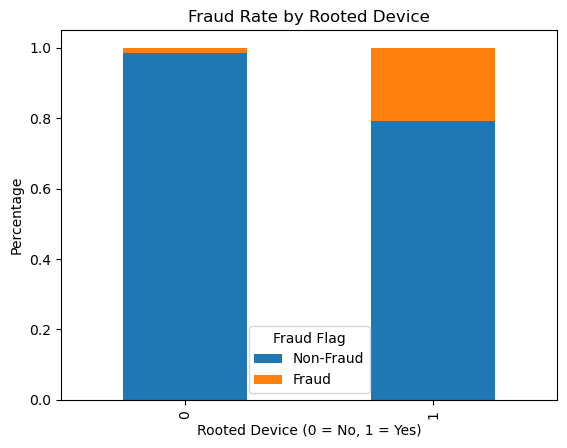

In [61]:
# Statistical test between fraud and rooted device

tran_device = pd.merge(dataframes['upi_transactions_history'],
                      dataframes['device_info'],
                      on = 'device_id', how= 'inner')

# Contingency table

table = pd.crosstab(tran_device['is_rooted'],tran_device['fraud_flag'])

# Chi2 test

chi2, p, dof, expected = chi2_contingency(table)

print(f'Chi2 : {chi2:.3f}')
print(f'P-Value : {p:.2f}')

if p<0.05:
    print('There is significant association between fraud and rooted device.')
else:
    print('No association between fraud and rooted device')


# Plot

table_percent = table.div(table.sum(axis=1), axis=0)

table_percent.plot(kind='bar', stacked=True)

plt.title('Fraud Rate by Rooted Device')
plt.xlabel('Rooted Device (0 = No, 1 = Yes)')
plt.ylabel('Percentage')
plt.legend(title='Fraud Flag', labels=['Non-Fraud', 'Fraud'])

plt.show()

Correlation: -0.002


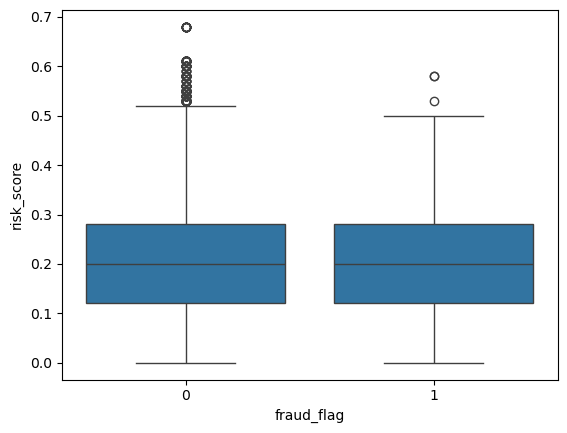

In [62]:
# Correlation between customer_risk Score transactions or fraud occurrence

cust = dataframes['customer_master'].copy()
tran = dataframes['upi_transactions_history'].copy()

merged_df = tran.merge(cust,on='customer_id',how='left')


# Correlation

corr = merged_df['risk_score'].corr(merged_df['fraud_flag'])

print(f'Correlation: {corr:.3f}')


# Box plot

import matplotlib.pyplot as plt
import seaborn as sns

sns.boxplot(x='fraud_flag',y='risk_score',data = merged_df)
plt.show()

In [63]:
dataframes['customer_master'].to_excel('customer_master.xlsx',index=False)
print('Successfully Downloaded to excel')

Successfully Downloaded to excel


In [64]:
dataframes['customer_feedback'].to_excel('customer_feedback.xlsx',index=False)
print('Successfully Downloaded to excel')

Successfully Downloaded to excel


In [65]:
dataframes['device_info'].to_excel('device_info.xlsx',index=False)
print('Successfully Downloaded to excel')

Successfully Downloaded to excel


In [66]:
dataframes['fraud_alert_history'].to_excel('fraud_alert_history.xlsx',index=False)
print('Successfully Downloaded to excel')

Successfully Downloaded to excel


In [67]:
dataframes['merchant_info'].to_excel('merchant_info.xlsx',index=False)
print('Successfully Downloaded to excel')

Successfully Downloaded to excel


In [68]:
dataframes['upi_account'].to_excel('upi_account.xlsx',index=False)
print('Successfully Downloaded to excel')

Successfully Downloaded to excel


In [ ]:
dataframes['upi_transactions_history'].to_excel('upi_transactions_history.xlsx',index=False)
print('Successfully Downloaded to excel')